# Lab 8: Análisis de datos de Múltiples Spike-Trains

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

### Introducción al análisis de datos  

Los datos que utilizaremos provienen de un estudio realizado por Snyder et al. (2015) con el objetivo de analizar la actividad neuronal a diferentes escalas. Para ello, se registró simultáneamente la actividad neuronal de monos macacos rhesus utilizando una matriz de 96 electrodos implantada en la corteza visual (área V4).

Nuestro interés principal es analizar la **correlación del conteo de picos (spike count correlation)**, una medida de la conectividad funcional entre neuronas. La conectividad funcional se refiere a la correlación en la actividad de diferentes neuronas o regiones cerebrales, lo que sugiere que pueden estar trabajando en conjunto. Un punto clave es que esta conectividad puede variar según las condiciones experimentales, lo que permite inferir relaciones funcionales entre las neuronas.  

### Diseño experimental  

Los registros provienen de una **matriz de microelectrodos Utah**, que consiste en una cuadrícula de 10 × 10 electrodos implantada en la corteza visual.

Cada electrodo capta señales de pequeñas poblaciones neuronales cercanas. Para aislar la actividad de neuronas individuales, los datos han sido previamente procesados mediante un método llamado **spike sorting**, que separa los picos de potencial eléctrico detectados por los electrodos y los asigna a neuronas específicas. En este ejercicio ya se ha realizado el spike-sorting.

Los datos se obtuvieron durante un experimento en el que los monos observaban **rejillas sinusoidales en movimiento** (imágenes con patrones de ondas sinusoidales), un estímulo visual comúnmente utilizado en neurociencia para activar neuronas de la corteza visual. Se realizaron **2300 ensayos**, cada uno de **2650 ms**, en los que se presentaron rejillas con dos orientaciones: **0° (barras horizontales)** y **90° (barras verticales)**.  


De los **2650 ms** de cada experimento **150 ms** corresponden a tiempo antes de presentación del estimulo en el que el mono es entrenado a ver una pantalla fijamente con un solo punto, **2000 ms** de presentación de estímulo y **500 ms** de terminación del experimento.

### Preguntas de investigación  

El análisis de datos abordará dos preguntas principales:  

1. **¿Las neuronas registradas responden al estímulo visual y muestran sensibilidad a la orientación de la rejilla?**  
2. **¿La estimulación con la rejilla sinusoidal incrementa la conectividad funcional entre las neuronas?**  
   - En caso afirmativo, ¿este aumento depende de la orientación del estímulo?  

### Hipótesis  

Dado que las neuronas de la corteza visual están sintonizadas a orientaciones específicas, esperamos que algunas neuronas respondan más a las rejillas en 0° y otras a las de 90°. Asimismo, se espera que la conectividad funcional aumente durante la estimulación visual, ya que las neuronas con la misma preferencia de orientación activarán en conjunto, mostrando correlaciones más altas en sus patrones de disparo.  

Este análisis nos permitirá explorar cómo las neuronas de la corteza visual procesan información y se conectan funcionalmente en respuesta a estímulos específicos.

## Datos

Los datos han sido recolectados en un archivo csv, haga uso de la librería pandas para importar los datos. En los datos encontrará 4 columnas.

 1. Channel: El canal dentro de los 96 electrodos donde fue registrado el spike. Para efectos de este ejercicio podemos suponer que cada electrodo corresponde a una neurona particular
 2. Time: El tiempo en el que se registró un spike en el canal (neurona). Tiempos negativos corresponden a tiempos antes de presentación del estímulo que se considera en t = 0.
 3. Orientation: La condición experimental en la que se registró el evento
     * 0: Barras Horizontales, 90: Barras Verticales
 4. Trial: El número del ensayo en el que se registró el evento

## Ejercicio 1

Realice un análisis exploratorio y responda las siguientes preguntas

1. Cuántas neuronas (canales) diferentes tenemos registrados en este experimento?

In [ ]:
# tiempos importantes
trial_start_time = -0.150
grating_on_time  = 0.0
grating_off_time = 2.0
trial_end_time   = 2.5

In [ ]:
# Importamos los datos:
data = pd.read_csv('multielectrode_data.csv')
channel = data["channel"]
time = data["time"]
orientation = data["orientation"]
trial = data["trial"]

In [ ]:
# Canales o neuronas distintas en el experimento:
len(channel.unique())

20

2. Seleccione el canal 63 y el 80 y para cada uno de los dos canales haga 2 raster plots en los que muestre los spikes generados durante los 1150 ensayos para las franjas verticales y los 1150 ensayos horizontales. Describa las diferencias cualitativas en ambos casos.
    * **Nota:** Es posible que el rasterplot sea muy denso si desea mostrar los 1150 ensayos, si esto sucede restrinja el raster plot solo para visualziar los primeros 500 ensayos

In [ ]:
# Neurona 63:
data__63_vertical = data[(orientation == 90) & (channel == 63)]
data_63_horizontal = data[(orientation == 0) & (channel == 63)]

# Neurona 80:
data_80_vertical = data[(orientation == 90) & (channel == 80)]
data_80_horizontal = data[(orientation == 0) & (channel == 80)]

In [ ]:
# Separo en tiempo y ensayo:
time_63_vertical = data__63_vertical["time"]
time_63_horizontal = data_63_horizontal["time"]
time_80_vertical = data_80_vertical["time"]
time_80_horizontal = data_80_horizontal["time"]

trial_63_vertical = data__63_vertical["trial"]
trial_63_horizontal = data_63_horizontal["trial"]
trial_80_vertical = data_80_vertical["trial"]
trial_80_horizontal = data_80_horizontal["trial"]

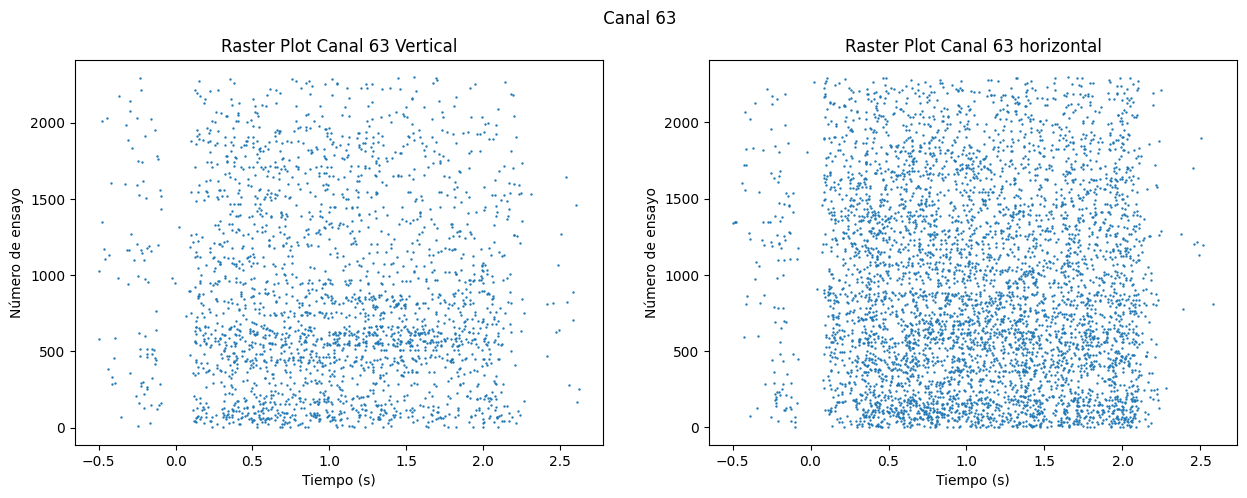

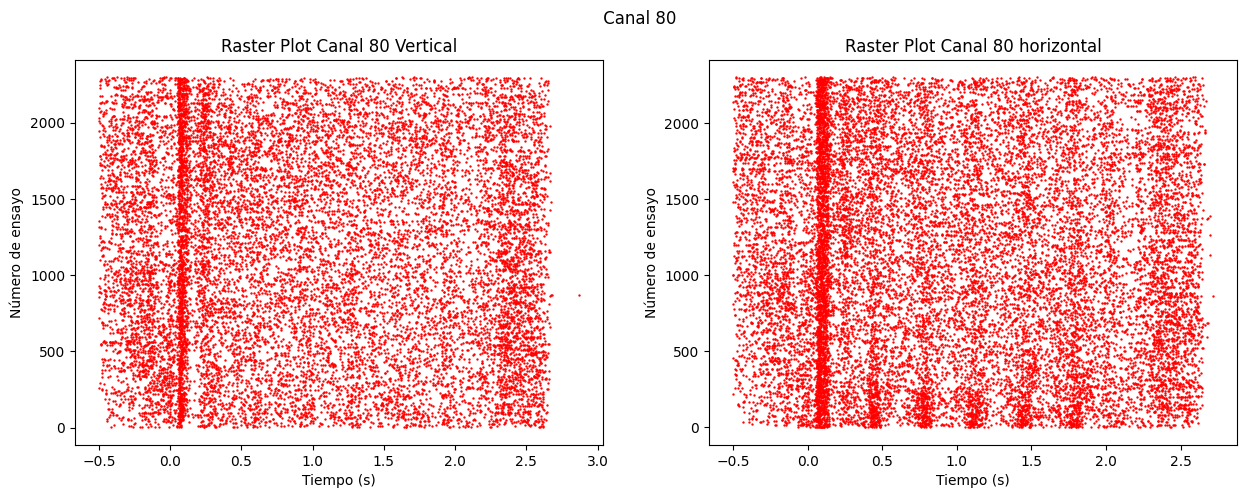

In [ ]:
plt.figure(figsize=(15, 5))
# Grafico:
plt.subplot(1, 2, 1)
plt.scatter(time_63_vertical, trial_63_vertical, s=0.5)
plt.title("Raster Plot Canal 63 Vertical")
plt.xlabel("Tiempo (s)")
plt.ylabel("Número de ensayo")
plt.subplot(1, 2, 2)
plt.scatter(time_63_horizontal, trial_63_horizontal, s=0.5)
plt.title("Raster Plot Canal 63 horizontal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Número de ensayo")
plt.suptitle(" Canal 63")
plt.show()

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.scatter(time_80_vertical, trial_80_vertical, s=0.5, color = "red")
plt.title("Raster Plot Canal 80 Vertical")
plt.xlabel("Tiempo (s)")
plt.ylabel("Número de ensayo")
plt.subplot(1, 2, 2)
plt.scatter(time_80_horizontal, trial_80_horizontal, s=0.5, color = "red")
plt.title("Raster Plot Canal 80 horizontal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Número de ensayo")
plt.suptitle(" Canal 80")
plt.show()

Se evidencia que la Neurona del canal 80 es más receptiva que la neurona del canal 63. También se puede afirmar que ambas neuronas son más receptivas a las lineas horizontales, ya que se activa más en estas ocasiones que con las lineas verticales.

## Ejercicio 2

Tome los datos de los mismos canales anteriores y calcule el PSTH para ambas condiciones. Grafique el PSTH justo debajo del raster plot correspondiente. Utilice un binning de 10 milisegundos para el histograma. Describa cómo el PSTH refleja lo que ocurre en el raster plot.

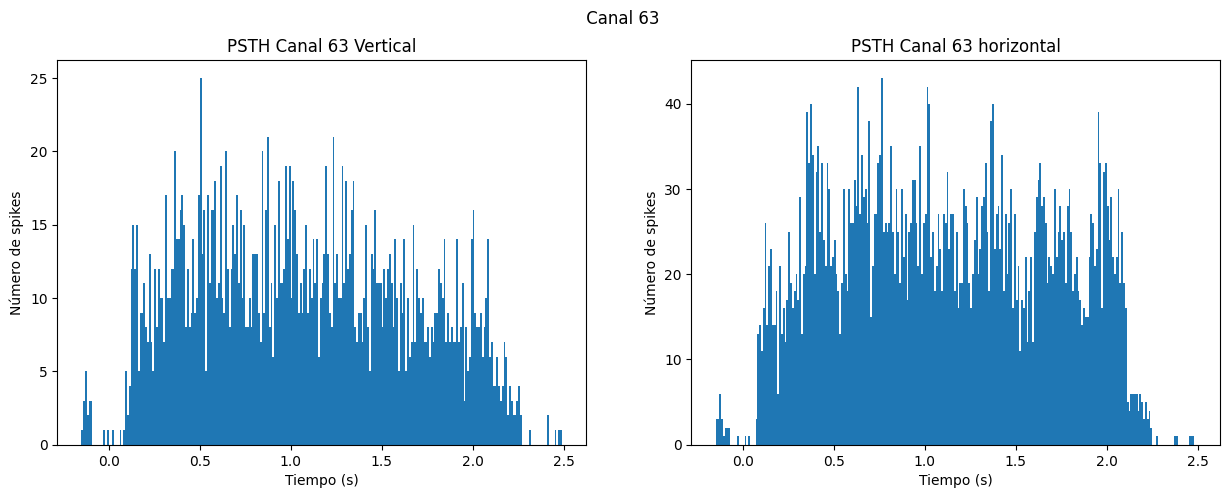

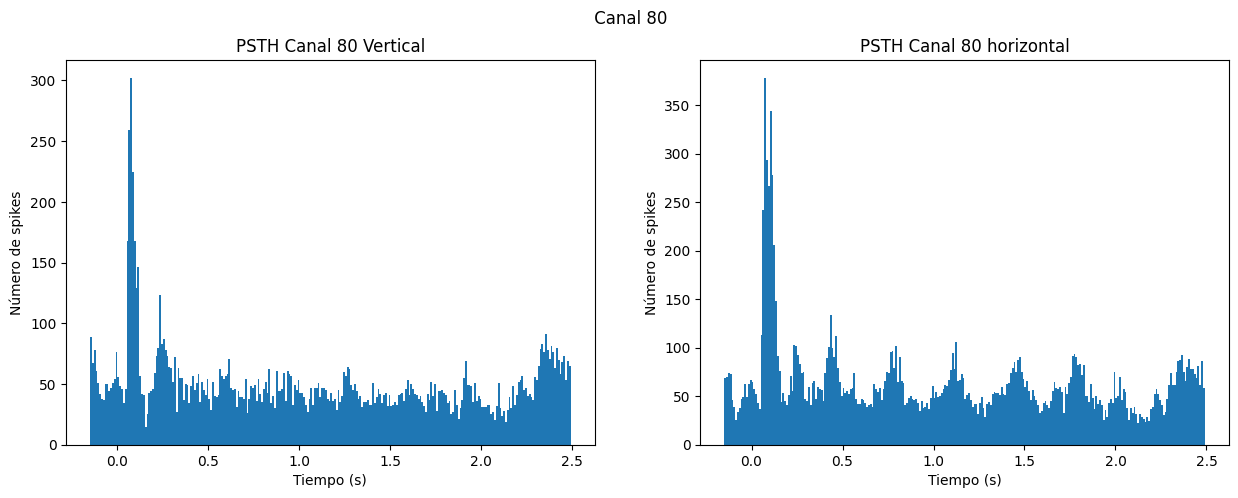

In [ ]:
bins = np.arange(trial_start_time, trial_end_time, 0.01)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.hist(time_63_vertical,bins=bins)
plt.title("PSTH Canal 63 Vertical")
plt.xlabel("Tiempo (s)")
plt.ylabel("Número de spikes")
plt.subplot(1, 2, 2)
plt.hist(time_63_horizontal,bins=bins)
plt.title("PSTH Canal 63 horizontal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Número de spikes")
plt.suptitle(" Canal 63")
plt.show()

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.hist(time_80_vertical,bins=bins)
plt.title("PSTH Canal 80 Vertical")
plt.xlabel("Tiempo (s)")
plt.ylabel("Número de spikes")
plt.subplot(1, 2, 2)
plt.hist(time_80_horizontal,bins=bins)
plt.title("PSTH Canal 80 horizontal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Número de spikes")
plt.suptitle(" Canal 80")
plt.show()

Notemos que al inicio del estimulo se genera gran cantidad de spike en la neurona 80, y con las lineas orientadas de forma horizontal también hay momentos en donde se activa la neurona (en varios trials), representando de buena manera los raster plot. En cuanto a la neurona 63, podemos afirmar en ambas imágenes que no hay un momento en que haya tenido muchas activaciones como ocurre con el canal 80.

## Ejercicio 3

Muestre en un arreglo de 20 subplots los PSTH correspondientes a la orientación de 0 y 90 para todas las neuronas.

In [ ]:
def generar_arreglo(neurona):
  data_neurona_hor = data[(data["channel"] == neurona) & (data["orientation"] == 0)]
  data_neurona_ver = data[(data["channel"] == neurona) & (data['orientation'] == 90)]
  time_neurona_hor = data_neurona_hor["time"]
  time_neurona_ver = data_neurona_ver["time"]
  bins = np.arange(trial_start_time, trial_end_time, 0.01)
  plt.hist(time_neurona_hor,bins=bins,label="Horizontal")
  plt.hist(time_neurona_ver,bins=bins, label="Vertical",alpha=0.8)
  plt.legend()
  plt.title("PSTH Canal " + str(neurona))
  plt.xlabel("Tiempo (s)")
  plt.ylabel("Número de spikes")

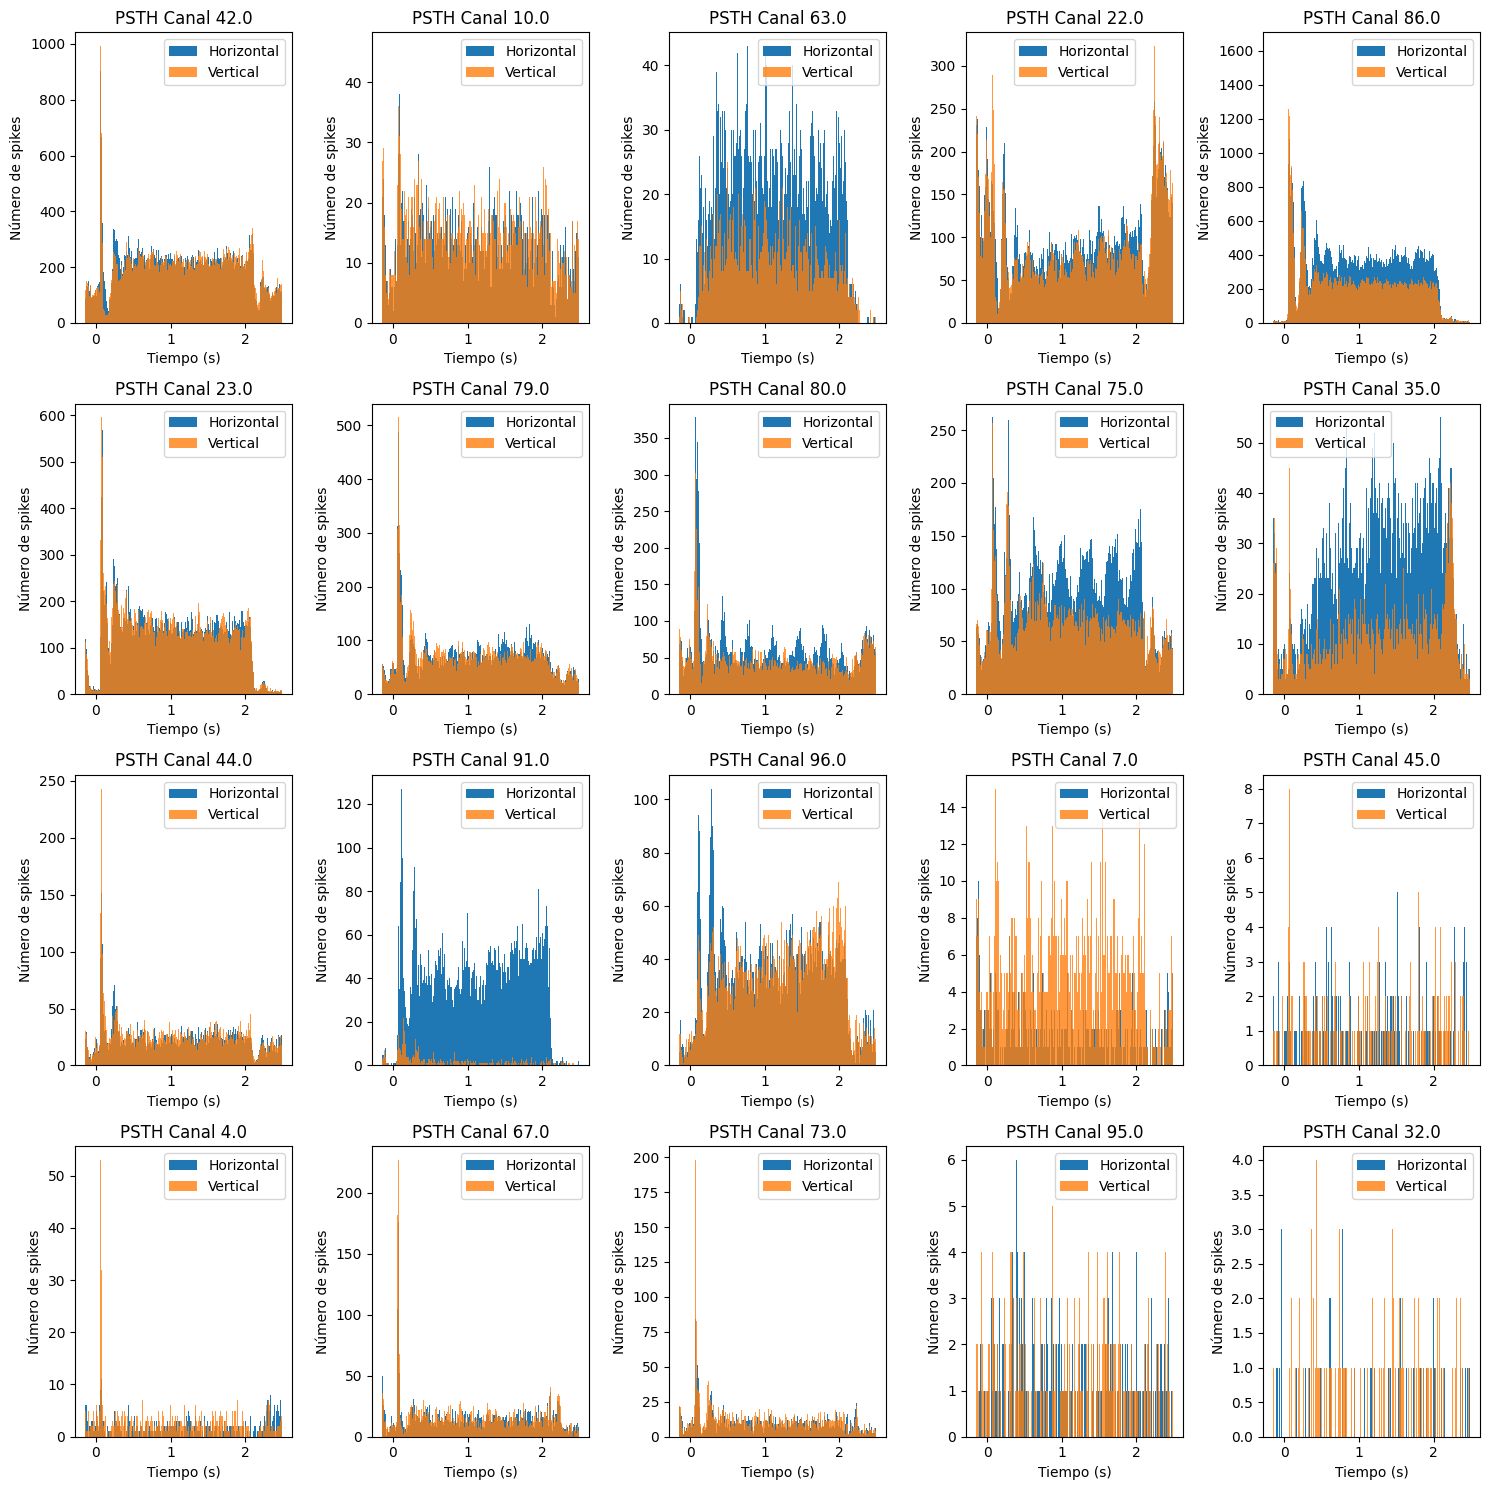

In [ ]:
cont = 1
plt.figure(figsize=(15, 15))
for neurona in data["channel"].unique():
  plt.subplot(4, 5, cont)
  generar_arreglo(neurona)
  cont += 1
plt.tight_layout()
plt.show()

## Ejercicio 4:

Recuerde que el experimento original tenía 96 canales, sin embargo en los datos anteriores solo vimos 20 de ellos. Esto es porque los datos originales con los datos de los spikes de todos los canales para los 3000 ensayos sería excesivamente grande para trabajar. Sin embargo ya hemos visto que el PSTH nos da una información reducida de los que ocurre en cada canal para los 3000 experimentos. En el archivo *array_psth.csv* que encontrará a continuación se encuentran los PSTH ya calculados para las 96 neuronas para los primeros 2150 ms de experimento. Para esto se ha usado un binning de 8ms.

Cargue el archivo y muestre la matriz de correlación entre los PSTH de las diferentes neuronas. La matriz resultante es la matriz de conectividad funcional. Restrinja su análisis a los datos correspondientes al intervalo de estimulación.

Encuentra diferencias entre las conectividades funcionales entre las distintas neuronas para las orientaciones de 0 y 90?

In [23]:
# Importamos los datos:
data2 = pd.read_csv('array_psth.csv')
data_horizontal = data2[(data2["orientation"]==0)]
data_vertical = data2[(data2["orientation"]==90)]

In [24]:
intervalos = np.arange(trial_start_time, grating_off_time, 0.008)
indice_estimulo = np.where(intervalos >= 0)[0][0]
eliminar = ["orientation"]
for i in range(indice_estimulo):
  eliminar.append(f"{i}")
data_estimulo_horizontal = data_horizontal.drop(columns=eliminar,axis=1)
data_estimulo_vertical = data_vertical.drop(columns=eliminar,axis=1)

In [25]:
# Lo pasamos a numpy para hacer correlacion entre filas, que es justamente entre los PSTH de las diferentes neuronas.
estimulo_horizontal = data_estimulo_horizontal.set_index('channel')
estimulo_horizontal = estimulo_horizontal.astype("float").T
estimulo_vertical = data_estimulo_vertical.set_index('channel')
estimulo_vertical = estimulo_vertical.astype("float").T

In [26]:
corr_horizontal = estimulo_horizontal.corr()
corr_vertical = estimulo_vertical.corr()

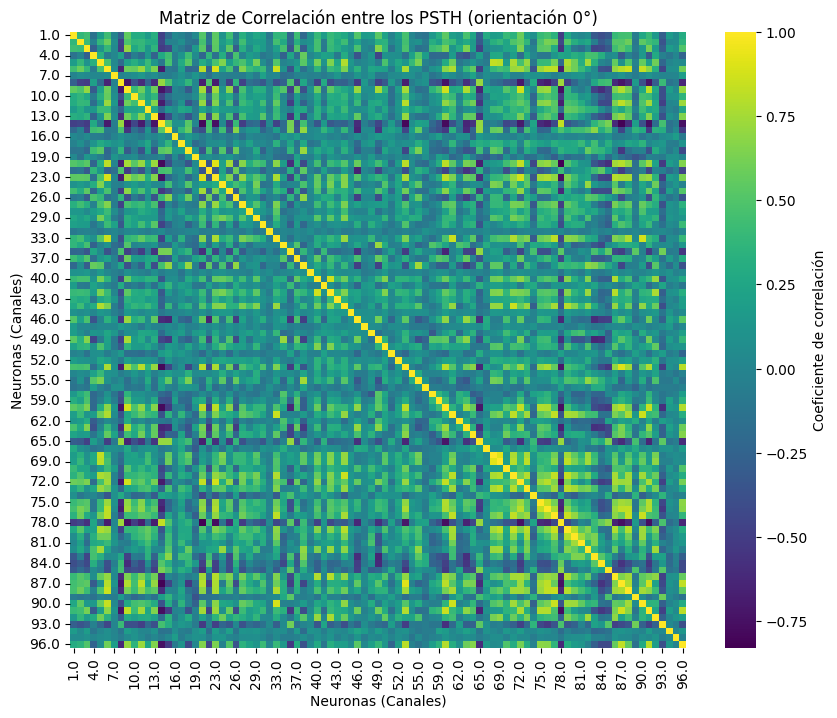

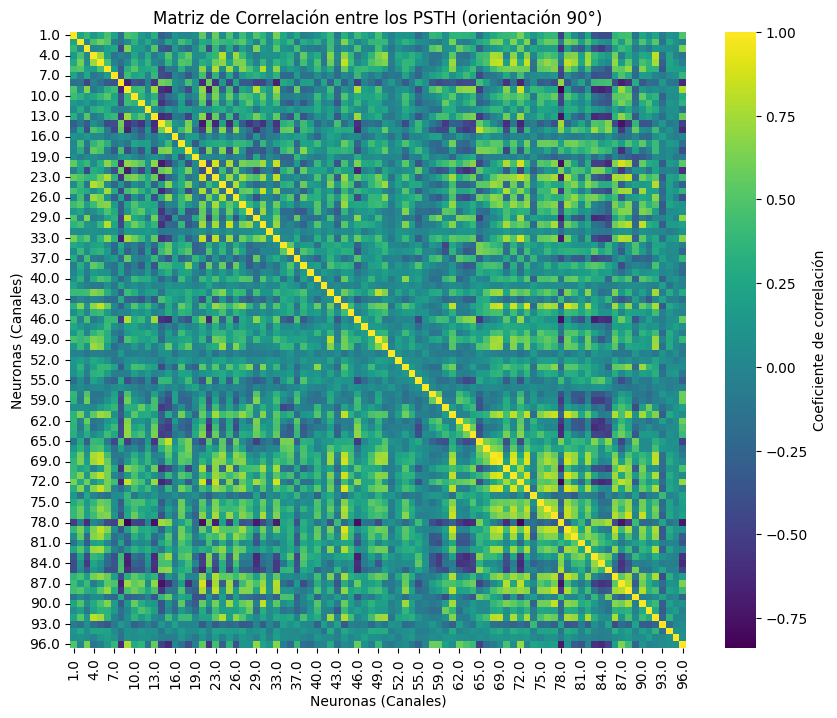

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_horizontal, cmap="viridis", square=True,
            cbar_kws={'label': 'Coeficiente de correlación'})
plt.title("Matriz de Correlación entre los PSTH (orientación 0°)")
plt.xlabel("Neuronas (Canales)")
plt.ylabel("Neuronas (Canales)")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_vertical, cmap="viridis", square=True,
            cbar_kws={'label': 'Coeficiente de correlación'})
plt.title("Matriz de Correlación entre los PSTH (orientación 90°)")
plt.xlabel("Neuronas (Canales)")
plt.ylabel("Neuronas (Canales)")

plt.show()

In [28]:
# Matriz de correlación con dos decimales
print("Matriz de Correlación Estimulo horizontal:")
display(corr_horizontal.round(2))

Matriz de Correlación Estimulo horizontal:


channel,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,87.0,88.0,89.0,90.0,91.0,92.0,93.0,94.0,95.0,96.0
channel,,,,,,,,,,,,,,,,,,,,,
1.0,1.00,0.37,0.43,-0.13,0.17,0.43,-0.01,-0.28,0.55,0.30,...,0.44,0.45,-0.07,0.26,0.40,0.15,-0.28,0.16,0.05,0.30
2.0,0.37,1.00,0.41,-0.02,0.38,0.58,0.06,-0.48,0.49,0.37,...,0.50,0.59,-0.11,0.54,0.44,0.38,-0.36,0.04,0.05,0.35
3.0,0.43,0.41,1.00,-0.28,0.10,0.38,0.03,-0.51,0.70,0.27,...,0.54,0.42,-0.07,0.14,0.62,0.16,-0.28,0.18,0.09,0.50
4.0,-0.13,-0.02,-0.28,1.00,0.33,-0.07,0.02,0.20,-0.30,-0.06,...,-0.31,-0.02,-0.14,0.15,-0.32,0.28,-0.03,-0.11,0.01,-0.25
5.0,0.17,0.38,0.10,0.33,1.00,0.47,0.02,-0.21,0.20,0.31,...,0.09,0.49,-0.03,0.56,0.18,0.59,-0.23,0.01,0.05,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92.0,0.15,0.38,0.16,0.28,0.59,0.32,0.03,-0.30,0.28,0.19,...,0.21,0.41,-0.03,0.35,0.24,1.00,-0.27,0.02,0.12,0.18
93.0,-0.28,-0.36,-0.28,-0.03,-0.23,-0.44,0.01,0.41,-0.39,-0.39,...,-0.42,-0.35,0.60,-0.27,-0.48,-0.27,1.00,0.03,-0.06,-0.39
94.0,0.16,0.04,0.18,-0.11,0.01,0.08,0.00,-0.13,0.18,0.10,...,0.12,0.07,0.03,-0.00,0.17,0.02,0.03,1.00,0.02,0.14


In [29]:
# Matriz de correlación con dos decimales
print("Matriz de Correlación Estimulo Vertical:")
display(corr_vertical.round(2))

Matriz de Correlación Estimulo Vertical:


channel,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,87.0,88.0,89.0,90.0,91.0,92.0,93.0,94.0,95.0,96.0
channel,,,,,,,,,,,,,,,,,,,,,
1.0,1.00,0.24,0.38,0.14,0.26,0.46,0.22,-0.16,0.48,0.41,...,0.43,0.44,-0.14,0.25,0.07,0.23,-0.07,0.11,0.07,0.49
2.0,0.24,1.00,0.03,0.46,0.61,0.50,-0.05,-0.14,0.04,0.34,...,0.17,0.50,0.04,0.49,0.21,0.52,-0.15,0.27,0.10,-0.01
3.0,0.38,0.03,1.00,0.01,0.04,0.18,0.27,-0.46,0.66,0.16,...,0.40,0.31,-0.11,0.03,-0.11,0.13,0.08,0.07,0.05,0.63
4.0,0.14,0.46,0.01,1.00,0.72,0.19,-0.12,-0.03,-0.09,0.26,...,-0.08,0.26,0.04,0.27,0.23,0.82,-0.18,0.24,-0.02,-0.12
5.0,0.26,0.61,0.04,0.72,1.00,0.46,-0.04,-0.18,0.04,0.39,...,0.15,0.53,0.05,0.46,0.35,0.75,-0.28,0.25,0.13,-0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92.0,0.23,0.52,0.13,0.82,0.75,0.35,-0.01,-0.19,0.07,0.35,...,0.11,0.46,0.05,0.41,0.28,1.00,-0.24,0.35,0.02,0.00
93.0,-0.07,-0.15,0.08,-0.18,-0.28,-0.34,-0.09,0.15,0.00,-0.27,...,-0.19,-0.27,0.22,-0.30,-0.31,-0.24,1.00,-0.14,0.03,0.06
94.0,0.11,0.27,0.07,0.24,0.25,0.22,0.03,-0.12,0.10,0.06,...,0.12,0.22,-0.01,0.20,0.08,0.35,-0.14,1.00,0.10,0.08


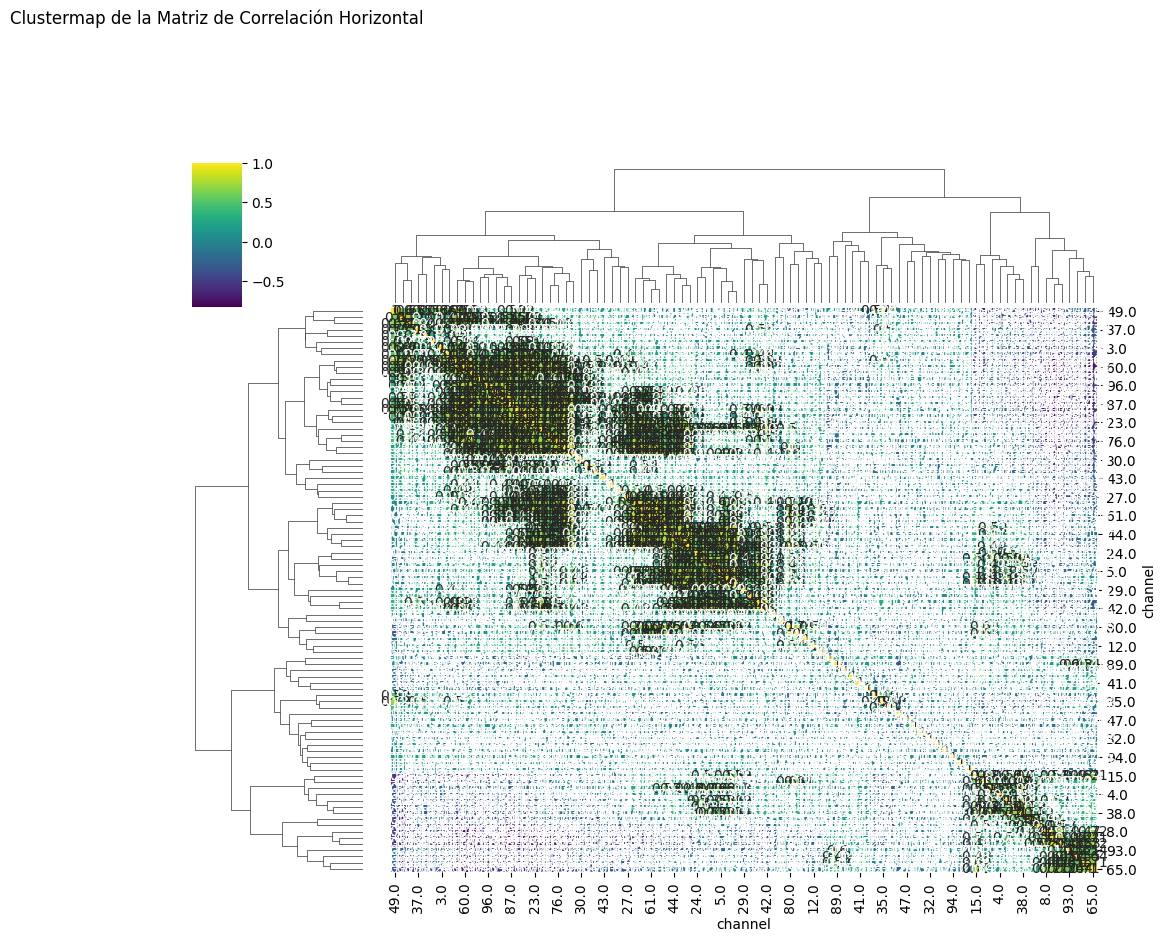

In [31]:
# Clustermap de la matriz de correlación
sns.clustermap(corr_horizontal, annot=True, cmap='viridis', figsize=(10, 8))
plt.title('Clustermap de la Matriz de Correlación Horizontal', pad=100)
plt.show()

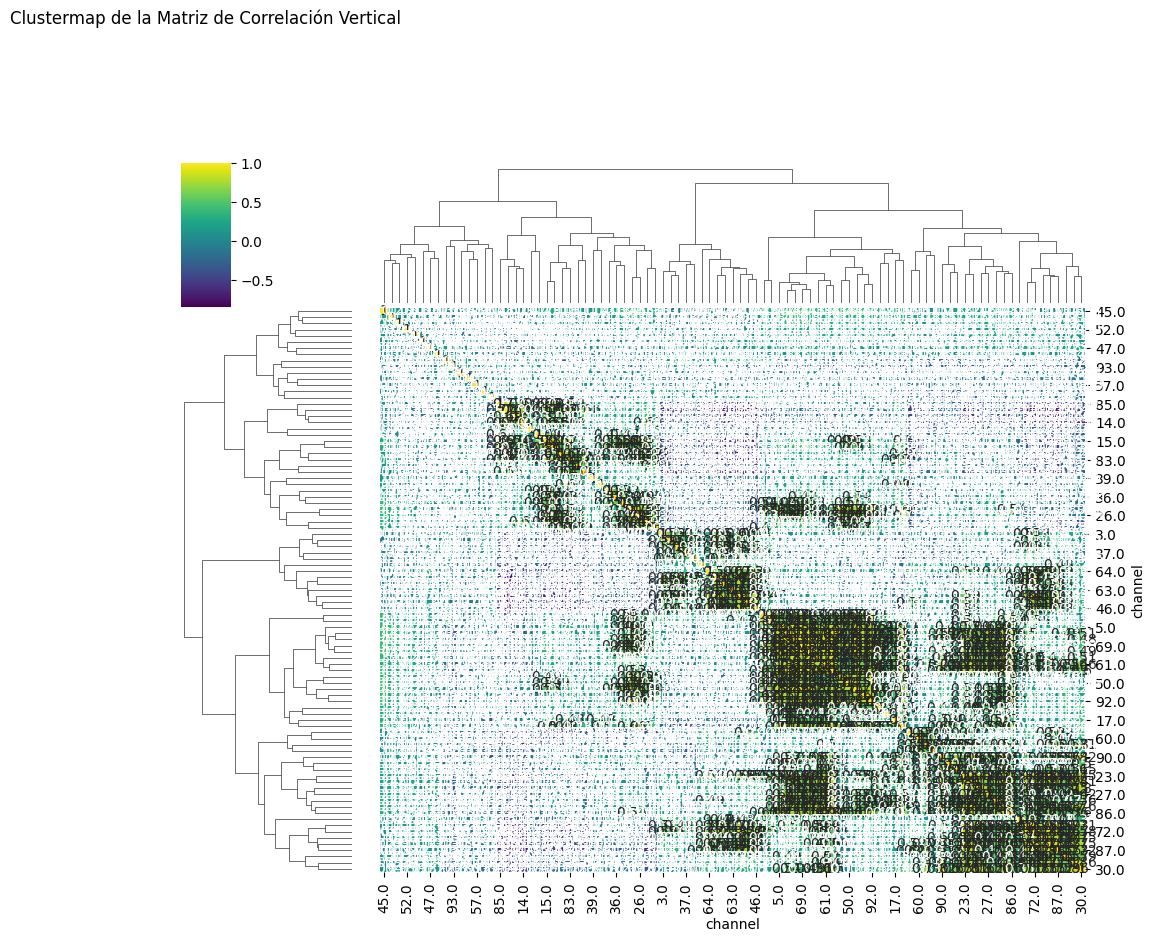

In [32]:
sns.clustermap(corr_vertical, annot=True, cmap='viridis', figsize=(10, 8))
plt.title('Clustermap de la Matriz de Correlación Vertical', pad=100)
plt.show()

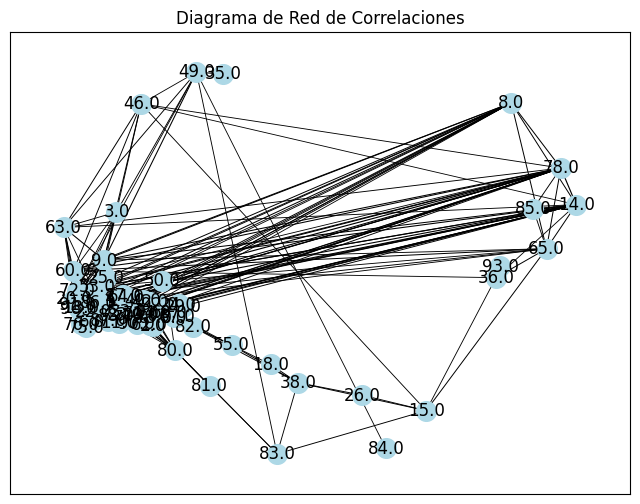

In [33]:
import networkx as nx

# Definir un umbral para considerar solo correlaciones fuertes
threshold = 0.6

# Crear el grafo a partir de la matriz de correlación
G = nx.Graph()
for i in corr_horizontal.columns:
    for j in corr_horizontal.columns:
        if i != j and abs(corr_horizontal.loc[i, j]) > threshold:
            G.add_edge(i, j, weight=corr_horizontal.loc[i, j])

# Dibujar el grafo
plt.figure(figsize=(8, 6))
edges = G.edges(data=True)
pos = nx.spring_layout(G)
weights = [abs(data['weight']) for (_, _, data) in edges]
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=200)
nx.draw_networkx_edges(G, pos, width=weights)
nx.draw_networkx_labels(G, pos)
plt.title('Diagrama de Red de Correlaciones')
plt.show()


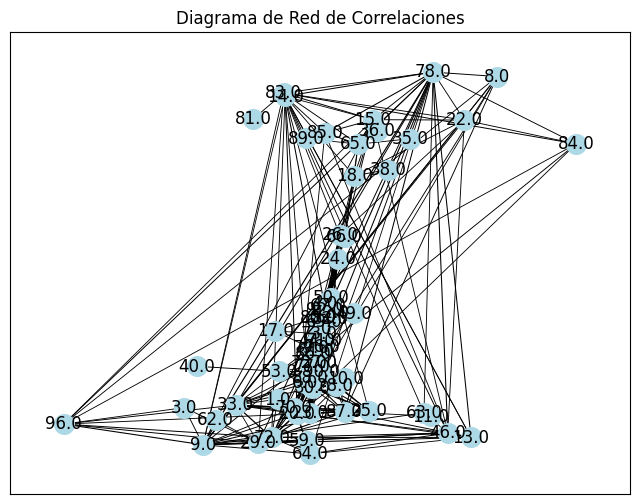

In [34]:
import networkx as nx

# Definir un umbral para considerar solo correlaciones fuertes
threshold = 0.6

# Crear el grafo a partir de la matriz de correlación
G = nx.Graph()
for i in corr_vertical.columns:
    for j in corr_vertical.columns:
        if i != j and abs(corr_vertical.loc[i, j]) > threshold:
            G.add_edge(i, j, weight=corr_vertical.loc[i, j])

# Dibujar el grafo
plt.figure(figsize=(8, 6))
edges = G.edges(data=True)
pos = nx.spring_layout(G)
weights = [abs(data['weight']) for (_, _, data) in edges]
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=200)
nx.draw_networkx_edges(G, pos, width=weights)
nx.draw_networkx_labels(G, pos)
plt.title('Diagrama de Red de Correlaciones')
plt.show()


A pesar de haber utilizado varios métodos para comparar las correlaciones, no encontramos algún factor que diferencie o nos permita concluir sobre algún incremento de la sinápsis entre las neuronas al modificar la forma del estímulo, si bien es cierto que al cambiar dicha forma algunas neuronas se activan más (Como vimos en los puntos anteriores), tenemos que su plasticidad no cambia notoriamente.

Aunque la diferencia no es notable también se puede ver que para los canales cercanos entre si se presenta mayor correlación en sus PSTH, mostrándonos que su fuerza sináptica entre ellos es mayor, de hecho en los canales más altos se presenta una correlación positiva, haciendo que si uno dispara los demás canales también produzcan spikes.

Levemente se ve mayor correlación cuando se hace un estimulo con lineas verticales, y aunque vale la pena recalcar la diferencia, no es una diferencia alta. En los clustermap presentados podremos visualizar con más facilidad esta diferencia.